In [15]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

In [16]:
def find_flow(road_flow, intersection_flow, approach):
    """
    Estimates traffic flow for the entire day.
    Args:
        road_flow: 24-hour baseline road profile (hourly).
        intersection_flow: 15-minute traffic sums from real-world data.
        approach: target column from intersection_flow.
    Returns:
        ndarray: 24-hour traffic flow in 15-minute counts
    """
    pchip_road_flow = PchipInterpolator(np.arange(0, 1381, 60), road_flow)
    timeblock_midpoints = np.arange(7.5,1440,15)
    road_flow_15min = pchip_road_flow(timeblock_midpoints)

    valid_intersection_data = intersection_flow[intersection_flow[approach].notna()]
    
    real_data_idx = valid_intersection_data.index
    real_data_time = real_data_idx * 15 + 7.5
    real_data_sums = valid_intersection_data[approach].values

    road_intersection_multipliers = real_data_sums / road_flow_15min[real_data_idx]

    first_multiplier = road_intersection_multipliers[0] # 7:00
    last_multiplier = road_intersection_multipliers[-1] # 16:45
    
    pchip_multipliers = PchipInterpolator(real_data_time, road_intersection_multipliers)

    real_data_start_idx = real_data_idx.min()
    real_data_end_idx = real_data_idx.max()
    intersection_flow_multipliers = pchip_multipliers(timeblock_midpoints[real_data_start_idx:real_data_end_idx+1]) 

    intersection_flow_before = road_flow_15min[:real_data_start_idx] * first_multiplier
    intersection_flow_interpolated = intersection_flow_multipliers * road_flow_15min[real_data_start_idx:real_data_end_idx+1]
    intersection_flow_after = road_flow_15min[real_data_end_idx+1:] * last_multiplier

    intersection_flow_res = np.concatenate((intersection_flow_before, intersection_flow_interpolated, intersection_flow_after))
    intersection_flow_res = np.clip(intersection_flow_res, 0, None)

    for i in range(80, len(intersection_flow_res)):
        if intersection_flow_res[i] > intersection_flow_res[i-1]:
            intersection_flow_res[i] = intersection_flow_res[i-1] * 0.95

    idx_2200 = 88
    for i in range(idx_2200, len(intersection_flow_res)):
        intersection_flow_res[i] = np.minimum(intersection_flow_res[i], intersection_flow_res[idx_2200])
    
    return intersection_flow_res.astype(int)

In [17]:
road_flow = pd.read_csv("hourly_flow_percentage.csv")
intersection_flow = pd.read_csv("traffic_modlinska_swiatowida_kolacinska.csv")

directions = {
    'N_R': "RetailResIn",
    'N_S': "Jablonna",
    'N_L': "ResidentialIn",
    'N_U': "Jablonna",
    'S_R': "ResidentialIn",
    'S_S': "Legionowo",
    'S_L': "MixedIn",
    'S_U': "Legionowo",
    'SW_R': "MixedOut",
    'SW_S': "ResidentialIn",
    'SW_L': "RetailResOut",
    'SW_U': "MixedOut",
    'NE_R': "ResidentialOut",
    'NE_S': "ResidentialOut",
    'NE_L': "ResidentialOut",
    'NE_U': "ResidentialOut"
}

modeled_data = {
    "Time": intersection_flow["Time"].values
}

for approach, direction in directions.items():
     modeled_data[approach] = find_flow(road_flow[direction], intersection_flow, approach)

modeled_df = pd.DataFrame(modeled_data)
modeled_df.to_csv("traffic_modeled_24h_modlinska_swiatowida_kolacinska.csv", index=False)    

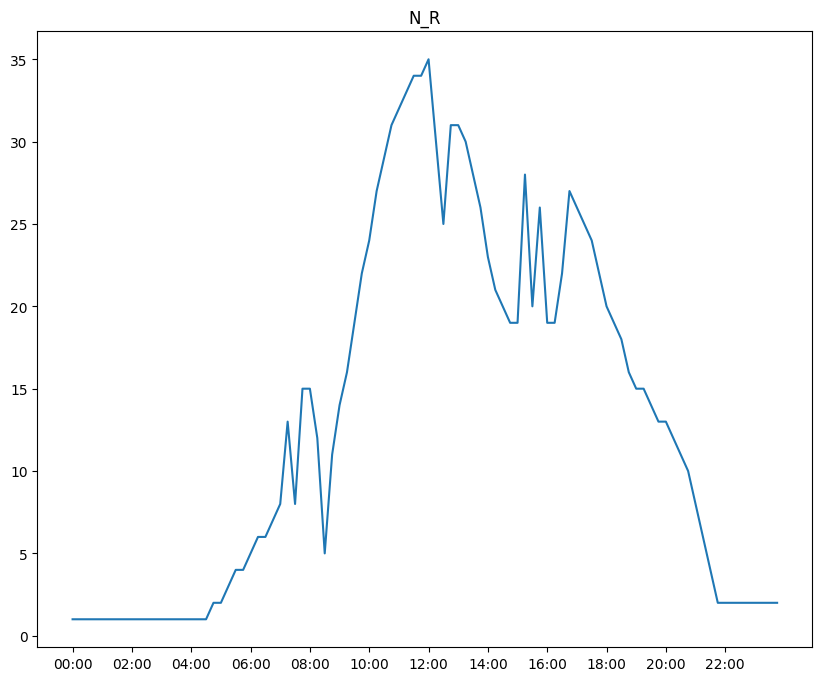

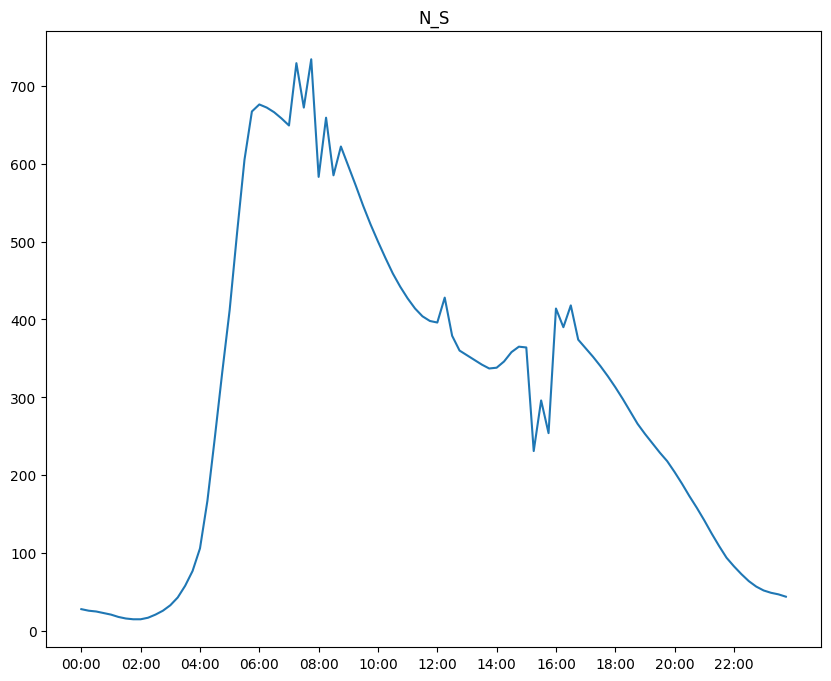

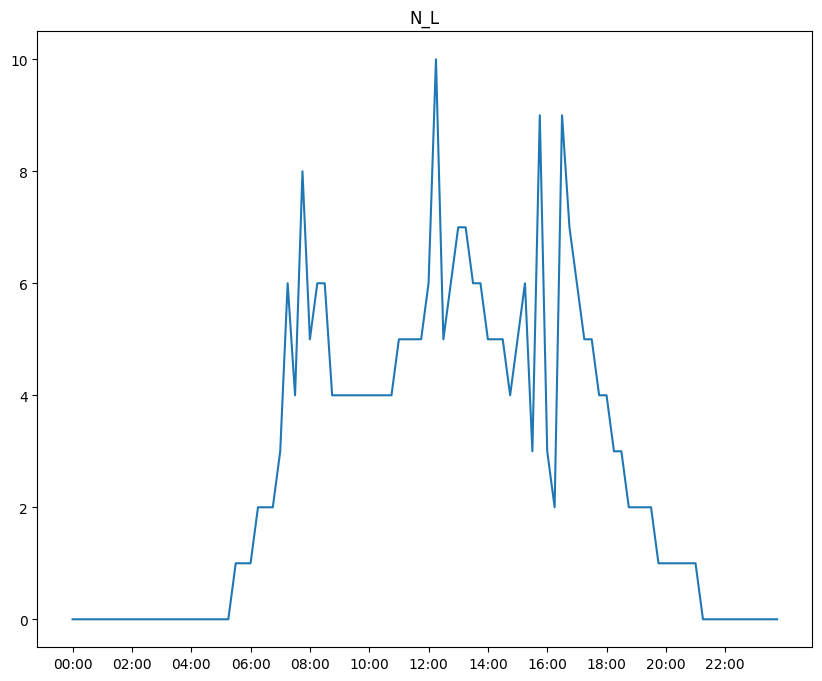

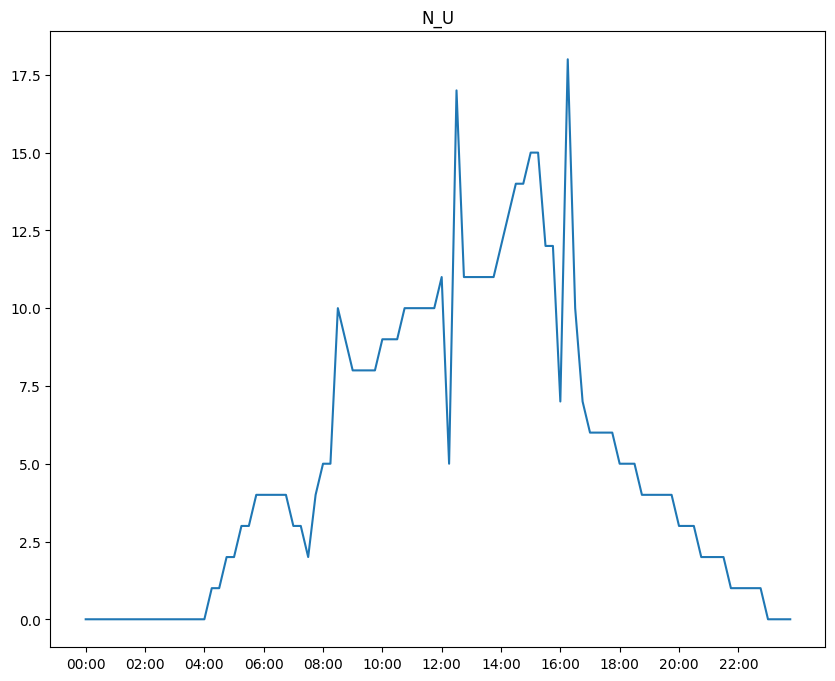

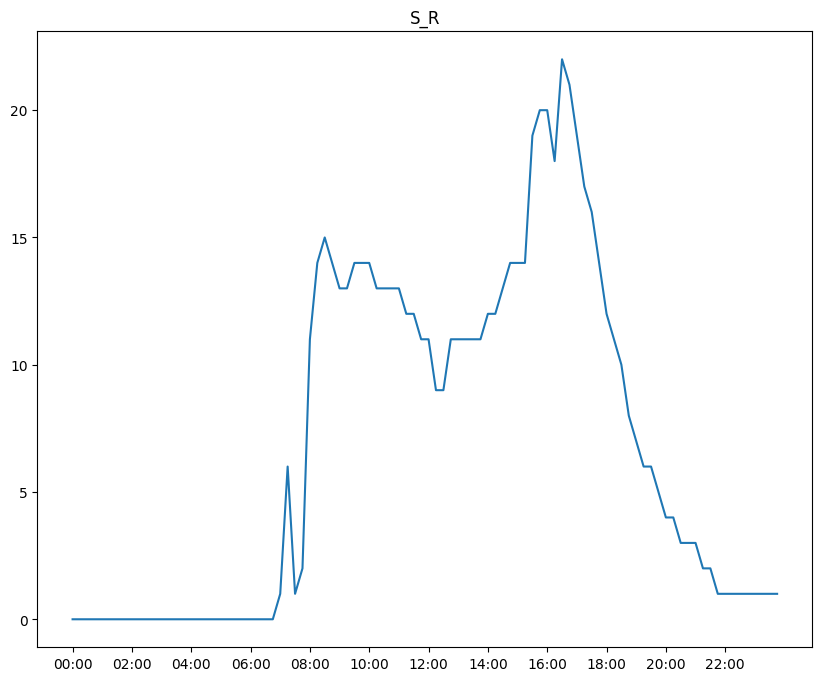

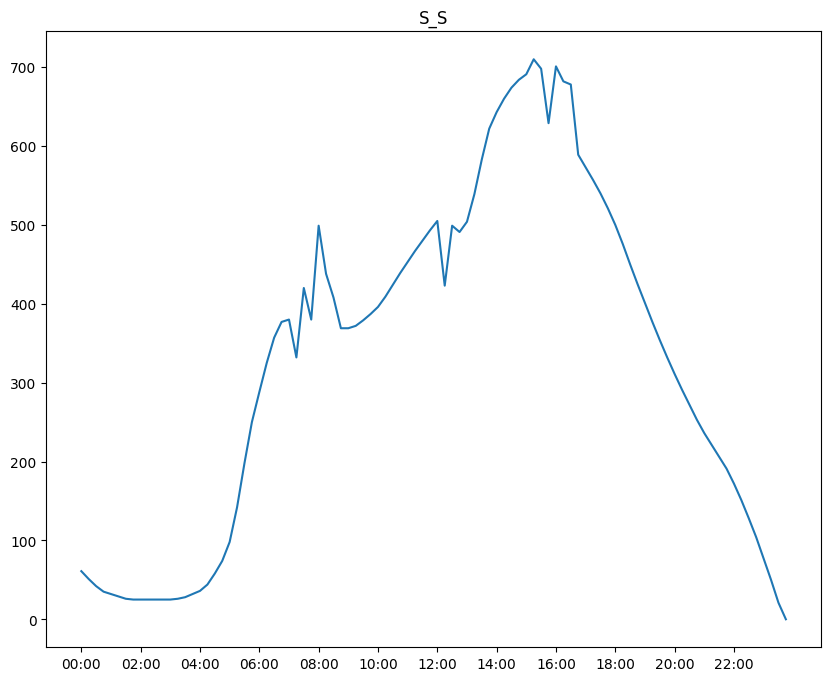

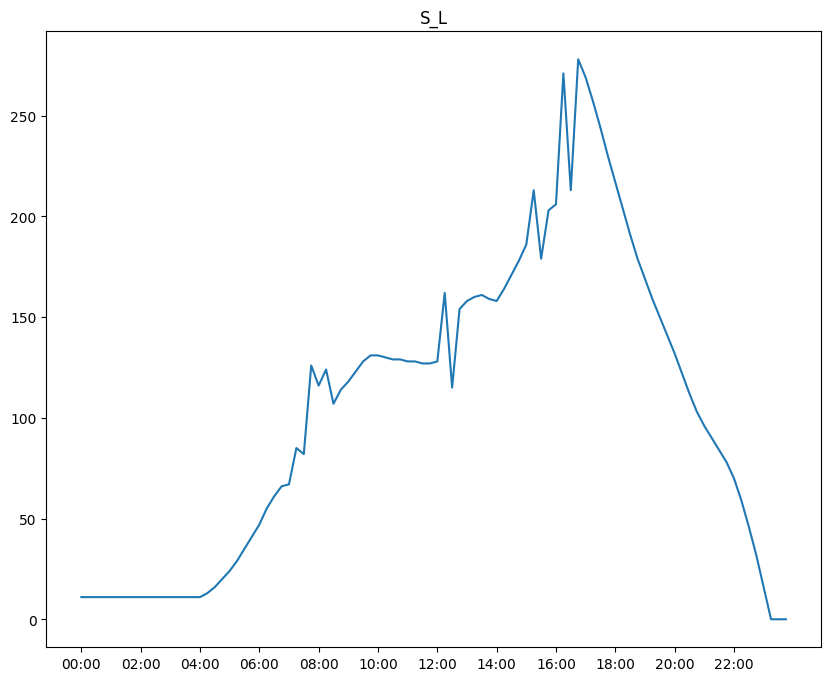

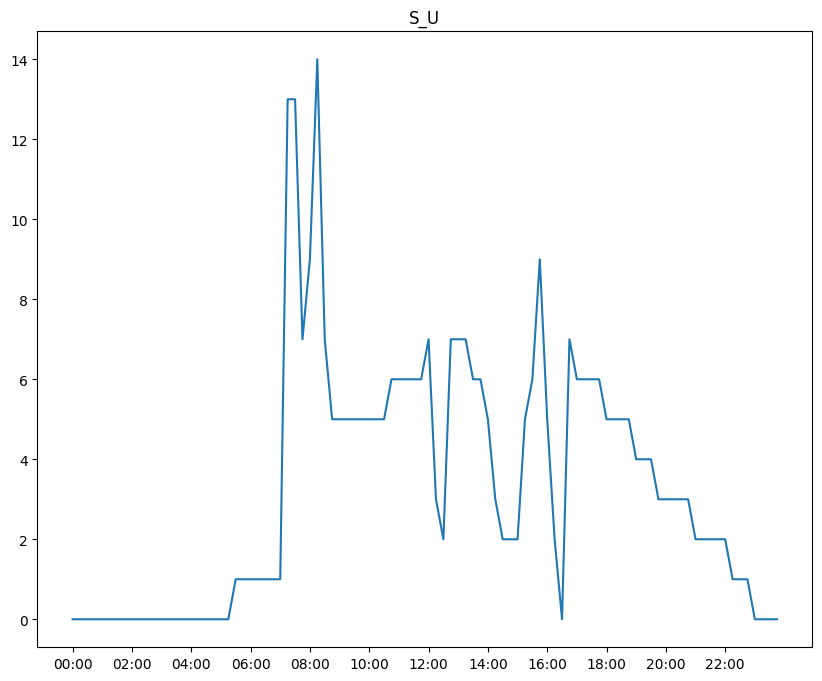

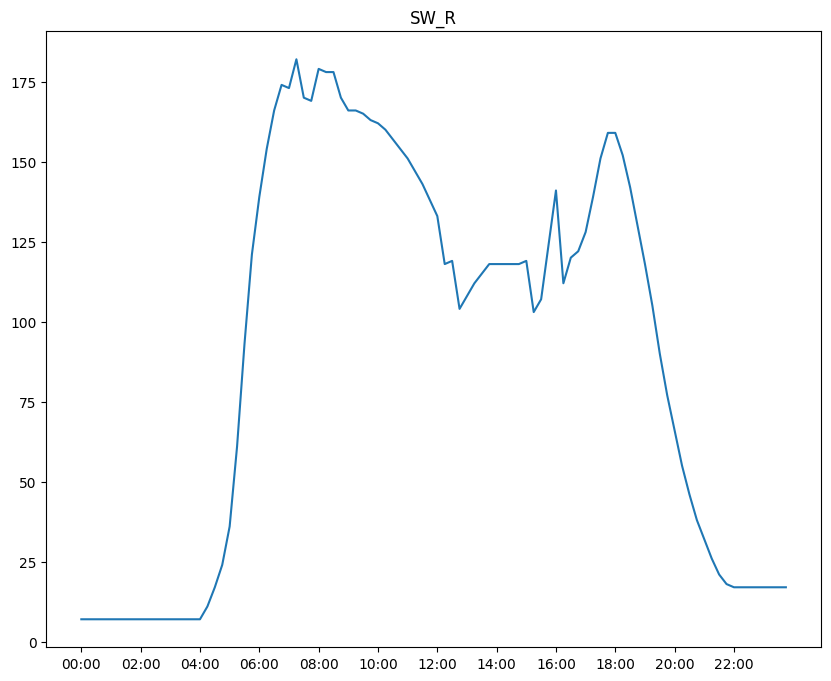

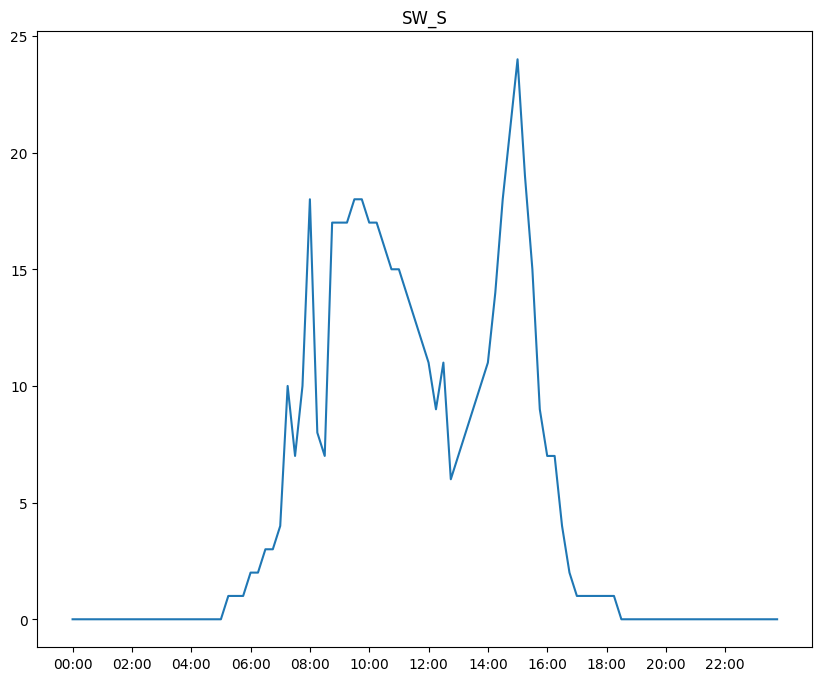

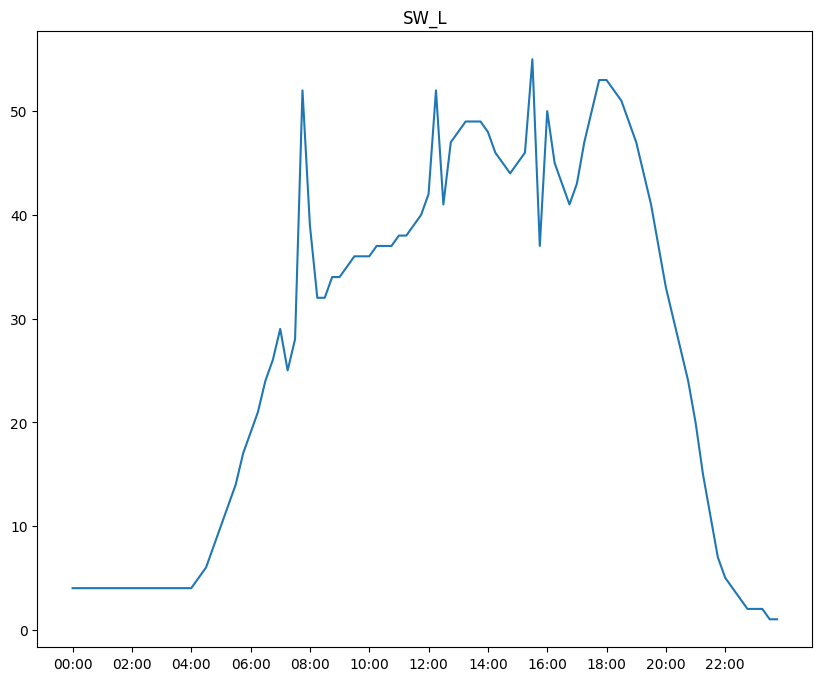

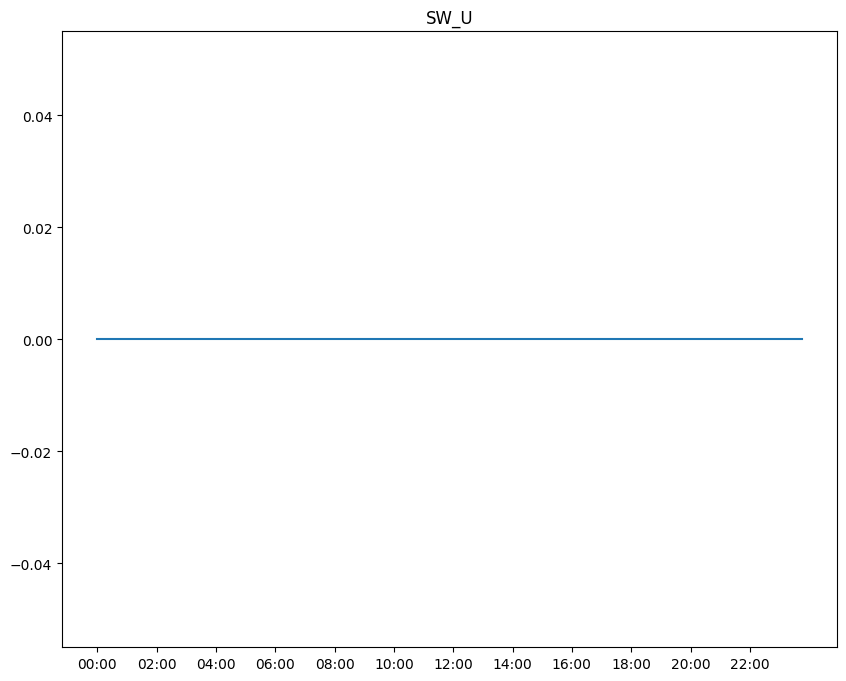

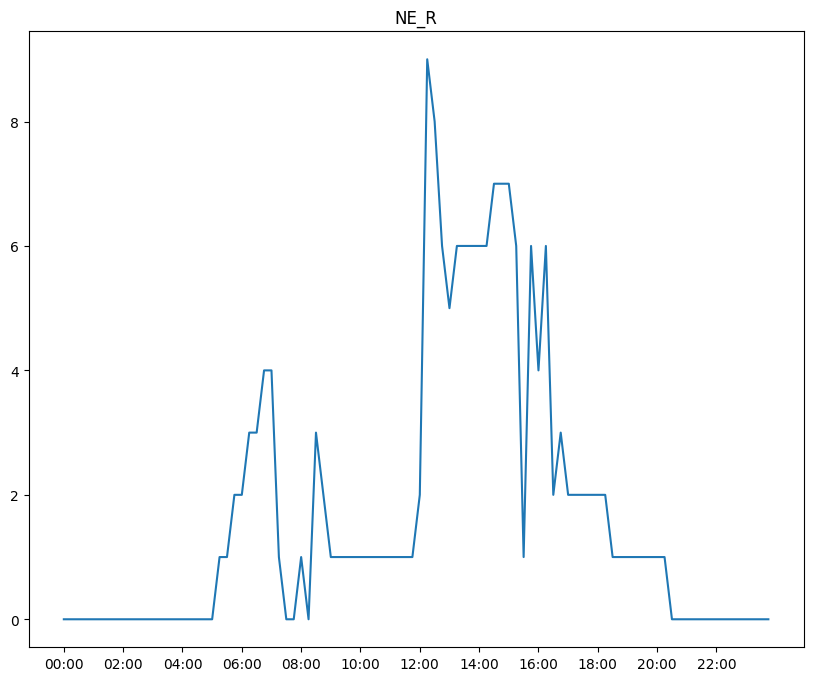

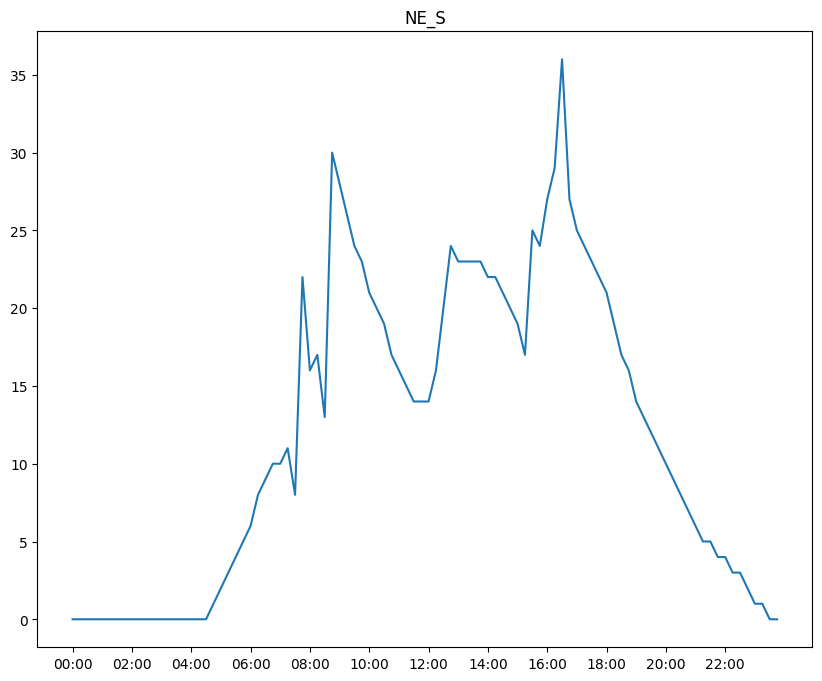

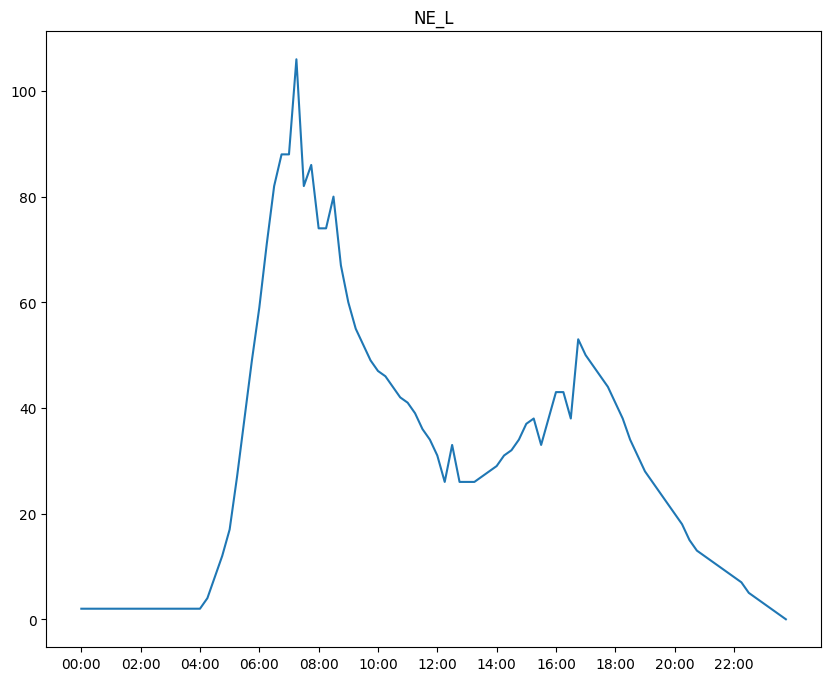

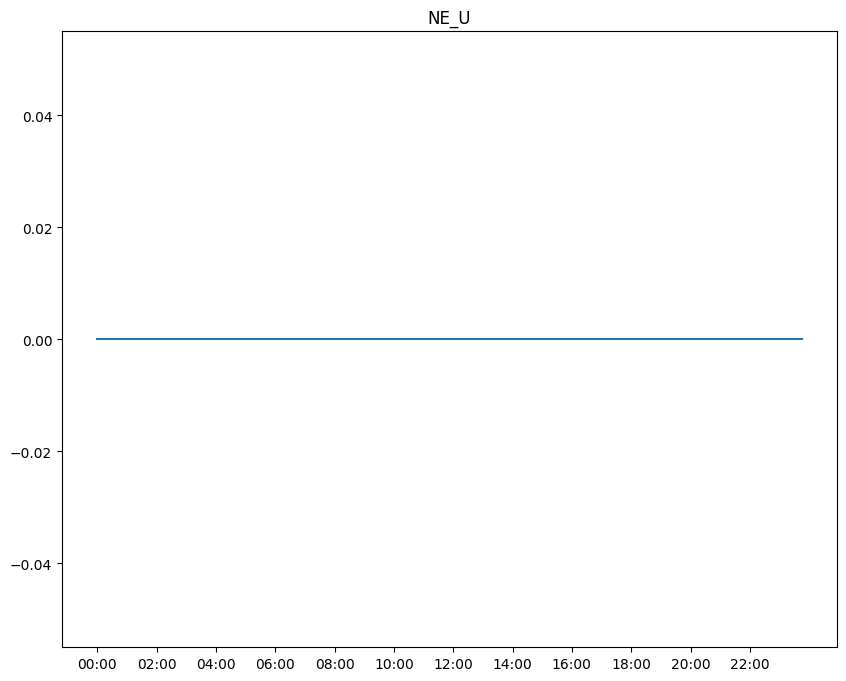

In [18]:
flows = pd.read_csv("traffic_modeled_24h_modlinska_swiatowida_kolacinska.csv")
labels = flows["Time"].values
x = np.arange(0, len(labels))

for column_name in flows.columns:
    if column_name == "Time":
        continue

    plt.figure(figsize=(10,8))
    plt.plot(x,flows[column_name].values)
    plt.xticks(x[::8],labels[::8])
    plt.title(f"{column_name}")
    plt.show()
    